In [61]:
pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
print("openpyxl installed successfully")


import warnings
warnings.filterwarnings("ignore")

openpyxl installed successfully


In [63]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Product Name,Sales,Delivery Days,Year,Month,Day
0,ORD1000,2025-04-13,2025-04-15,Same Day,Corporate,India,Vijayawada,KA,East,Technology,Tables,Eco Paper,3703.22,2,2025,4,13
1,ORD1001,2025-12-15,2025-12-18,First Class,Consumer,India,Vijayawada,TN,East,Furniture,Accessories,Wood Table,3861.85,3,2025,12,15
2,ORD1002,2025-09-28,2025-09-29,First Class,Corporate,India,Hyderabad,KA,North,Technology,Phones,Zen Chair,2573.74,1,2025,9,28
3,ORD1003,2025-04-17,2025-04-22,First Class,Consumer,India,Vijayawada,AP,North,Furniture,Phones,Laptop Stand,2762.17,5,2025,4,17
4,ORD1004,2025-03-13,2025-03-14,Same Day,Home Office,India,Chennai,TN,West,Furniture,Paper,Wood Table,2618.58,1,2025,3,13


In [64]:
df.shape

(200, 17)

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       200 non-null    str           
 1   Order Date     200 non-null    datetime64[us]
 2   Ship Date      200 non-null    datetime64[us]
 3   Ship Mode      200 non-null    str           
 4   Segment        200 non-null    str           
 5   Country        200 non-null    str           
 6   City           200 non-null    str           
 7   State          200 non-null    str           
 8   Region         200 non-null    str           
 9   Category       200 non-null    str           
 10  Sub-Category   200 non-null    str           
 11  Product Name   200 non-null    str           
 12  Sales          200 non-null    float64       
 13  Delivery Days  200 non-null    int64         
 14  Year           200 non-null    int32         
 15  Month          200 non-null    int

In [66]:
df.isnull()

,Order ID,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Product Name,Sales,Delivery Days,Year,Month,Day
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
196,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
197,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
198,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [67]:
df.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Segment          0
Country          0
City             0
State            0
Region           0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Delivery Days    0
Year             0
Month            0
Day              0
dtype: int64

In [68]:
df.duplicated().sum()

np.int64(0)

In [69]:
df = df.drop_duplicates()

In [70]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [71]:
df["Delivery Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day

In [72]:
df.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Segment          0
Country          0
City             0
State            0
Region           0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Delivery Days    0
Year             0
Month            0
Day              0
dtype: int64

In [73]:
# Fill numeric missing values (if any)
df["Sales"] = df["Sales"].fillna(df["Sales"].mean())

# Fill categorxical missing values (if any)
for col in ["City", "State", "Category", "Sub-Category"]:
    df[col] = df[col].fillna("Unknown")

In [74]:
df["Category"] = df["Category"].str.strip().str.title()
df["Sub-Category"] = df["Sub-Category"].str.strip().str.title()
df["City"] = df["City"].str.title()
df["State"] = df["State"].str.upper()

In [75]:
q1 = df["Sales"].quantile(0.25)
q3 = df["Sales"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df = df[(df["Sales"] >= lower) & (df["Sales"] <= upper)]

In [76]:
df["Sales"].sum()

np.float64(516012.12999999995)

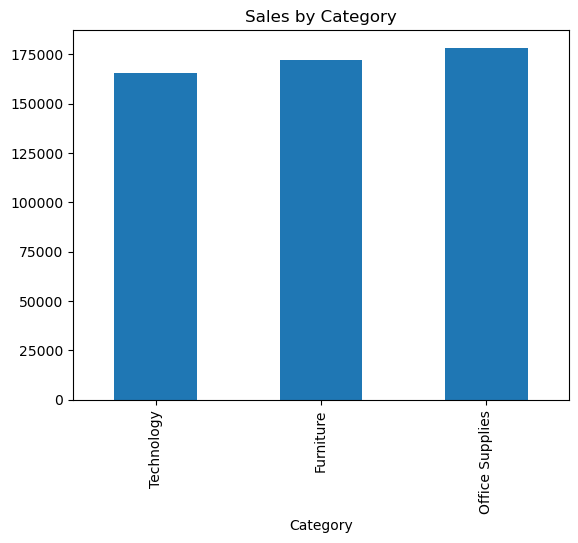

In [77]:
df.groupby("Category")["Sales"].sum().sort_values().plot(kind="bar")
plt.title("Sales by Category")
plt.show()

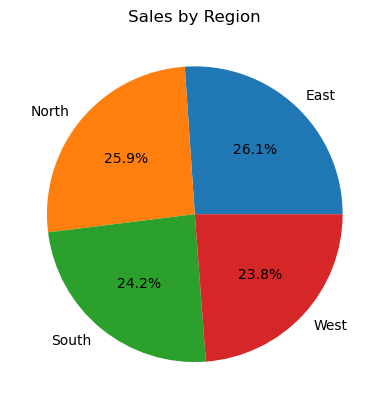

In [78]:
df.groupby("Region")["Sales"].sum().plot(kind="pie", autopct="%1.1f%%")
plt.title("Sales by Region")
plt.ylabel("")
plt.show()

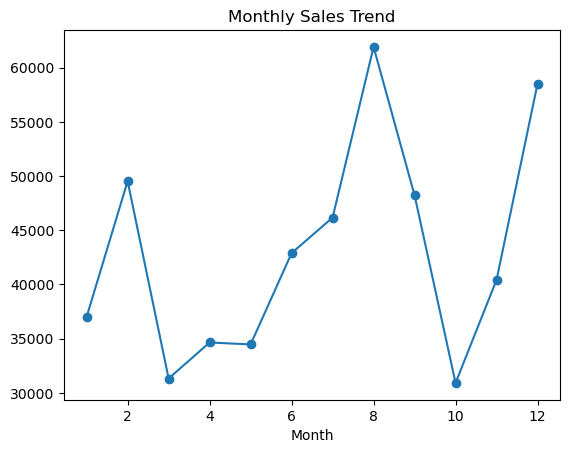

In [79]:
df.groupby("Month")["Sales"].sum().plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.show()

In [80]:
df.to_csv("cleaned_sales_dataset.csv", index=False)


In [81]:

summary = df.describe()

category_sales = df.groupby("Category")["Sales"].sum()
region_sales = df.groupby("Region")["Sales"].sum()
monthly_sales = df.groupby("Month")["Sales"].sum()

with pd.ExcelWriter(r"C:\Users\Jinugu Pallavi\OneDrive\Desktop\summer data science\project 4\sales_dataset.xlsx") as writer:
    df.to_excel(writer, index=False)
    summary.to_excel(writer, sheet_name="Summary")
    category_sales.to_excel(writer, sheet_name="Category Sales")
    region_sales.to_excel(writer, sheet_name="Region Sales")
    monthly_sales.to_excel(writer, sheet_name="Monthly Sales")

In [82]:
def data_pipeline(file_path):
    df = pd.read_csv(file_path)

    df = df.drop_duplicates()

    df["Order Date"] = pd.to_datetime(df["Order Date"])
    df["Ship Date"] = pd.to_datetime(df["Ship Date"])

    df["Delivery Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

    df["Category"] = df["Category"].fillna("Unknown")
    df["Sales"] = df["Sales"].fillna(df["Sales"].mean())

    q1 = df["Sales"].quantile(0.25)
    q3 = df["Sales"].quantile(0.75)
    iqr = q3 - q1
    df = df[(df["Sales"] >= q1 - 1.5*iqr) & (df["Sales"] <= q3 + 1.5*iqr)]

    df.to_csv("cleaned_output.csv", index=False)

    print("Pipeline executed successfully")
    return df

In [83]:
clean_df = data_pipeline(r"C:\Users\Jinugu Pallavi\OneDrive\Desktop\summer data science\project 4\sales_dataset.csv")
clean_df.head()

Pipeline executed successfully


,Order ID,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Product Name,Sales,Delivery Days,Year,Month,Day
0,ORD1000,2025-04-13,2025-04-15,Same Day,Corporate,India,Vijayawada,KA,East,Technology,Tables,Eco Paper,3703.22,2,2025,4,13
1,ORD1001,2025-12-15,2025-12-18,First Class,Consumer,India,Vijayawada,TN,East,Furniture,Accessories,Wood Table,3861.85,3,2025,12,15
2,ORD1002,2025-09-28,2025-09-29,First Class,Corporate,India,Hyderabad,KA,North,Technology,Phones,Zen Chair,2573.74,1,2025,9,28
3,ORD1003,2025-04-17,2025-04-22,First Class,Consumer,India,Vijayawada,AP,North,Furniture,Phones,Laptop Stand,2762.17,5,2025,4,17
4,ORD1004,2025-03-13,2025-03-14,Same Day,Home Office,India,Chennai,TN,West,Furniture,Paper,Wood Table,2618.58,1,2025,3,13
